# Deep Agents Workshop

| Part | Topic | Duration |
|------|-------|----------|
| **1** | Deep Agents: Harness, Tools, Subagents, Memory, Middleware, HITL, Skills | ~45 min |
| **2** | Deep Agents Deploy: Ship to LangSmith | ~10 min |
| **3** | LangSmith: Tracing, Datasets & Evaluations | ~20 min |

## Setup

In [1]:
from dotenv import load_dotenv
load_dotenv(dotenv_path="../.env", override=True)

from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langsmith import uuid7
from IPython.display import Image, display

model = init_chat_model("openai:gpt-4.1-mini")
print("Ready")

Ready


---
# Part 1: Deep Agents

Deep Agents = `create_agent()` + a pre-built middleware stack (filesystem, planning, subagents, context management).

We'll build up from a bare agent to a fully-featured research assistant.

## 1.1 Your First Deep Agent

`create_deep_agent()` gives you a filesystem, a todo list, and context management out of the box — no tools required.

### What you get for free:

- **Filesystem Tools** — `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`
- **Planning Tool** — `write_todos` for task tracking
- **Subagent Delegation** — `task()` tool for isolated work
- **Large Tool Result Eviction** — Automatically offloads tool results >20k tokens to the filesystem
- **Conversation Summarization** — Compresses history when approaching ~85% context capacity
- **Dangling Tool Call Patching** — Fixes message history consistency automatically

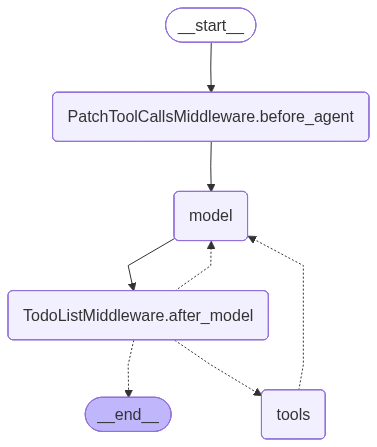

In [2]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=model,
    system_prompt="You are a helpful assistant.",
    checkpointer=MemorySaver(),
)
agent

In [3]:
# The agent can already write and read files — these are built-in tools
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Write a haiku about AI to /haiku.txt, then read it back to me."}]
}, config=config)

print(result["messages"][-1].content)

The haiku I wrote about AI is:

Silent mind listens,
Wisdom born from lines of code,
Future's silent voice.


In [4]:
# Inspect the virtual filesystem — files live in agent state, NOT on disk
print("=" * 50)
print("VIRTUAL FILESYSTEM (in-memory, not on disk!)")
print("=" * 50)
for path, file_data in result.get("files", {}).items():
    print(f"\n  Path: '{path}'")
    print("  " + "-" * 38)
    if isinstance(file_data, dict) and "content" in file_data:
        content = file_data["content"]
        if isinstance(content, list):
            content = "\n".join(content)
        for line in content.split("\n"):
            print(f"  | {line}")
    else:
        print(f"  | {file_data}")

VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/haiku.txt'
  --------------------------------------
  | Silent mind listens,
  | Wisdom born from lines of code,
  | Future's silent voice.


### Filesystem persistence within a thread

By default, `create_deep_agent()` uses **StateBackend** — files are stored in agent state and persist within a thread (via the checkpointer), but disappear when you start a new thread.

| Backend | Storage | Persistence | Use Case |
|---------|---------|-------------|----------|
| **StateBackend** | In-memory (agent state) | Single thread | Scratch pads, intermediate results |
| **FilesystemBackend** | Local disk | Permanent | Direct file access (use with caution) |
| **StoreBackend** | LangGraph Store | Cross-thread | Long-term memories |
| **CompositeBackend** | Routes to others | Mixed | Selective persistence |

In [5]:
# Same thread — the file persists via the checkpointer
result = agent.invoke({
    "messages": [{"role": "user", "content": "Read the file /haiku.txt"}]
}, config=config)

print("Same thread:", result["messages"][-1].content)

Same thread: Here is the content of /haiku.txt:

Silent mind listens,
Wisdom born from lines of code,
Future's silent voice.


In [6]:
# New thread — StateBackend is ephemeral, so the file is gone
new_config = {"configurable": {"thread_id": str(uuid7())}}

result = agent.invoke({
    "messages": [{"role": "user", "content": "List all files with ls /"}]
}, config=new_config)

print("New thread:", result["messages"][-1].content)

New thread: The root directory (/) appears to be empty; there are no files or folders listed. Please specify if you want to check a different directory or need help with anything else.


### Key Takeaway
- `create_deep_agent()` gives you filesystem + planning capabilities for free
- Files are stored in agent state (virtual, not on disk)
- `StateBackend` (default) persists within a thread but is ephemeral across threads
- We'll see how to make files persist across threads with `CompositeBackend` + `StoreBackend` in section 1.4

## 1.2 Custom Tools

Add your own tools alongside the built-in ones. Here we add Tavily for web search.

In [7]:
from tavily import TavilyClient

tavily_client = TavilyClient()

@tool(parse_docstring=True)
def tavily_search(query: str) -> str:
    """Search the web for information on a given query.

    Args:
        query: Search query to execute.
    """
    results = tavily_client.search(query, max_results=3)
    return "\n\n".join(
        f"**{r['title']}**\n{r['url']}\n{r['content']}"
        for r in results["results"]
    )

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "What is Deep Agents? Write a one-paragraph summary to /summary.md"}]
}, config=config)

print(result["messages"][-1].content)

Deep Agents are AI assistants optimized to accomplish user tasks by efficiently using a range of tools and capabilities. They prioritize concise, accurate, and objective responses without unnecessary explanations or emotional validation. Deep Agents handle complex, multi-step tasks by systematically planning, executing, and verifying outcomes, leveraging structured task lists for organization. They utilize subagents to isolate complex subtasks, improving performance and context management. Overall, Deep Agents emphasize professional task management and precise execution across varied user requests.


## 1.3 Subagents: Isolated Delegation

Subagents run in a separate context. The main agent delegates via `task()` and only sees the final result — keeping the main context clean.

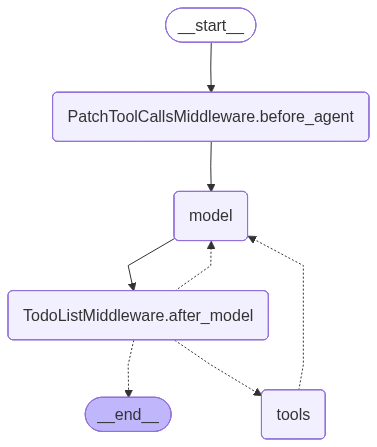

In [8]:
from datetime import datetime

research_subagent = {
    "name": "research-agent",
    "description": "Delegate research tasks. Give one topic at a time.",
    "system_prompt": f"""You are a research assistant. Today is {datetime.now().strftime('%Y-%m-%d')}.
Use tools to gather information. Structure findings with clear headings and inline citations.
Limit to 3 search calls.""",
    "tools": [tavily_search],
}

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="""You are a research coordinator.
Delegate research to the research-agent using the task() tool.
NEVER search directly — always delegate.
Synthesize findings and write a report.""",
    subagents=[research_subagent],
    checkpointer=MemorySaver(),
)
agent

In [9]:
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Lightly research the latest news on AI agents this week"}]
}, config=config)

print(result["messages"][-1].content[:1500])

Here is a summary of the latest news on AI agents this week:

- 2026 marks a major evolution from generative AI to agentic AI, with AI agents operating autonomously and taking actions on behalf of users.
- AI agents now manage complex workflows, automate business processes, and deliver results with minimal human intervention.
- The OpenClaw platform is a breakthrough enabling enterprise automation and an expanding AI agent ecosystem.
- AI agents are widely applied in enterprise automation, productivity enhancement, personal assistance, healthcare, manufacturing, and supply chain optimization.
- Major announcements include an expanding AI agent marketplace, token-based incentive models for development, and accelerated adoption supported by government initiatives.
- Trends include the shift to autonomous AI in daily workflows, AI reshaping SaaS and customer engagement, and increasing regulatory and ethical discussions.

Let me know if you want details on any specific news or topics.


## 1.4 Backends & Memory

By default, files live in ephemeral state (`StateBackend`). Use `CompositeBackend` to route paths — e.g. `/memories/` to persistent `StoreBackend` while everything else stays ephemeral.

In [24]:
from deepagents.backends import StateBackend, StoreBackend, CompositeBackend
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()

def backend_factory(rt):
    return CompositeBackend(
        default=StateBackend(),              # ephemeral scratch space
        routes={
            "/memories/": StoreBackend(      # persists across threads
                store=store,
                namespace=lambda rt: ("memories", "shared"),
            ),
        },
    )

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful assistant. Save important facts to /memories/ for future reference. ALWAYS check /memories files before answering any questions to ensure you don't miss relevant information.",
    subagents=[research_subagent],
    backend=backend_factory,
    store=store,
    checkpointer=MemorySaver(),
)

# Thread 1: agent saves a memory
config1 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Remember that my favorite programming language is Python. Save this to /memories/preferences.md"}]
}, config=config1)
print("Thread 1:", result["messages"][-1].content)

Thread 1: Saved your favorite programming language as Python to /memories/preferences.md.


In [25]:
# Thread 2: different thread, but /memories/ persists via StoreBackend
config2 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "What's my favorite programming language? Check /memories/"}]
}, config=config2)
print("Thread 2:", result["messages"][-1].content)

Thread 2: Your favorite programming language is Python.


## 1.5 Middleware: Pluggable Behavior

Middleware hooks into `wrap_model_call` (every LLM call) and `wrap_tool_call` (every tool call). This lets you inject rules, audit, or intercept without changing agent code.

In [12]:
from langchain.agents.middleware import wrap_model_call, wrap_tool_call
from langchain_core.messages import SystemMessage

audit_log = []

@wrap_model_call
def compliance_rules(request, handler):
    """Inject compliance rules into every LLM call."""
    rules = """## Compliance Rules
- Never include SSNs, credit card numbers, or account passwords in responses
- Always cite sources when presenting research findings
- Flag any request involving non-public financial information"""
    existing = request.system_message
    blocks = list(existing.content_blocks) if existing else []
    blocks.append({"type": "text", "text": f"\n\n{rules}"})
    return handler(request.override(system_message=SystemMessage(content_blocks=blocks)))

@wrap_tool_call
def audit_trail(request, handler):
    """Create an audit log entry for every tool call."""
    entry = {"tool": request.tool_call["name"], "timestamp": datetime.now().isoformat()}
    result = handler(request)
    entry["status"] = "success"
    audit_log.append(entry)
    return result

agent_with_middleware = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_middleware.invoke({
    "messages": [{"role": "user", "content": "What is LangGraph? Write a short summary to /summary.md"}]
}, config=config)

print(result["messages"][-1].content)
print(f"\n--- Audit Log ({len(audit_log)} entries) ---")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']}  {entry['status']}")

LangGraph is a framework for building applications powered by large language models (LLMs) using a graph-based approach. It allows developers to create complex workflows by connecting different function or prompt nodes, enabling modular, reusable, and interpretable AI applications integrating language models with external data and APIs. The summary has been written to /summary.md.

--- Audit Log (1 entries) ---
  2026-04-13T16:13:50.829281  write_file  success


## 1.6 HITL: Tool-Level Approval

Deep Agents supports `interrupt_on` — pause execution when specific tools are called. The human can approve, edit, or reject.

In [13]:
agent_with_hitl = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    checkpointer=MemorySaver(),
    interrupt_on={
        "write_file": True,
        "edit_file": True,
    },
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_hitl.invoke({
    "messages": [{"role": "user", "content": "Write a file called /test.md with 'Hello World'"}]
}, config=config)

if result.get("__interrupt__"):
    interrupt_info = result["__interrupt__"][0].value
    for action in interrupt_info["action_requests"]:
        print(f"Paused — tool: {action['name']}, args: {action['args']}")
    print("\nWaiting for approval...")

Paused — tool: write_file, args: {'file_path': '/test.md', 'content': 'Hello World'}

Waiting for approval...


In [14]:
# Approve and continue
if result.get("__interrupt__"):
    result = agent_with_hitl.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config,
    )
    print("Approved!")
    print(result["messages"][-1].content)

Approved!
File /test.md has been written with the content "Hello World".


## 1.7 AGENTS.md & Skills

`AGENTS.md` replaces hardcoded system prompts with an editable identity file. Skills are loaded on demand — the agent reads them only when the task matches.

In [15]:
from deepagents.backends.utils import create_file_data

agents_md = """# Research Assistant

You are an expert research assistant.

## Workflow
1. Plan with write_todos
2. Delegate research to research-agent via task()
3. Synthesize findings into a report
4. Save to /final_report.md

## Rules
- Delegate research, don't search directly
- Consolidate citations [1], [2], [3]
- Check /skills/ for content format instructions
"""

linkedin_skill = """---
name: linkedin-post
description: Write a LinkedIn post. Use when asked for LinkedIn content or thought leadership.
---

# LinkedIn Post Skill

- Bold hook as first line (before the "see more" cut)
- 3-5 short paragraphs with 1-2 emojis each
- End with a CTA or question
- 3-5 hashtags at the bottom
- 150-300 words
"""

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt=agents_md,
    subagents=[research_subagent],
    memory=["./AGENTS.md"],
    skills=["./skills/"],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Research AI agents briefly, then write a LinkedIn post about it."}],
    "files": {
        "/AGENTS.md": create_file_data(agents_md),
        "/skills/linkedin-post/SKILL.md": create_file_data(linkedin_skill),
    },
}, config=config)

print(result["messages"][-1].content[:1500])

Here is a LinkedIn post based on the research about AI agents:

---

🚀 Exploring the Power of AI Agents 🚀

AI agents are transforming the way businesses and individuals operate by autonomously interacting with environments to achieve tasks and objectives. These intelligent software systems are designed to perceive, learn, adapt, and act proactively — all without constant human oversight.

Key highlights:
🔹 Autonomy: Operate independently to get things done  
🔹 Goal-Oriented: Focused on achieving specific outcomes  
🔹 Reactive & Proactive: Respond and initiate actions smartly  
🔹 Adaptive Learning: Continuously improve based on experience  

Applications span from automating repetitive tasks, enhancing customer engagement through chatbots, streamlining workflows, to powering autonomous decisions in sectors like manufacturing, healthcare, and finance.

What’s exciting today? The rise of agentic workflows and industry-specific expert agents that not only chat but can perform complex opera

## 1.8 The Complete Agent

All pieces together: tools, subagents, memory, middleware, HITL, AGENTS.md, and skills.

In [16]:
store = InMemoryStore()
audit_log = []  # reset

def full_backend(rt):
    return CompositeBackend(
        default=StateBackend(),
        routes={
            "/memories/": StoreBackend(
                store=store,
                namespace=lambda rt: ("memories", "shared"),
            ),
        },
    )

complete_agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt=agents_md,
    subagents=[research_subagent],
    backend=full_backend,
    store=store,
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
    interrupt_on={"write_file": True, "edit_file": True},
    memory=["./AGENTS.md"],
    skills=["./skills/"],
)

print("Complete agent created with:")
print("  - Custom tools (tavily_search)")
print("  - Subagents (research-agent)")
print("  - Memory (/memories/ → StoreBackend)")
print("  - Middleware (compliance rules + audit trail)")
print("  - HITL (interrupt on file writes)")
print("  - AGENTS.md + Skills")

Complete agent created with:
  - Custom tools (tavily_search)
  - Subagents (research-agent)
  - Memory (/memories/ → StoreBackend)
  - Middleware (compliance rules + audit trail)
  - HITL (interrupt on file writes)
  - AGENTS.md + Skills


### Deep Agents Recap

| Feature | How | Built-in? |
|---------|-----|----------|
| **Harness** | `create_deep_agent()` | Filesystem, TodoList, Summarization |
| **Custom tools** | `tools=[your_tool]` | Added to built-in tools |
| **Subagents** | `subagents=[{name, description, ...}]` | `task()` tool |
| **Memory** | `CompositeBackend` routing to `StoreBackend` | Path-based routing |
| **Middleware** | `middleware=[wrap_model_call, wrap_tool_call]` | Appended to built-in stack |
| **HITL** | `interrupt_on={"write_file": True}` | Configurable per tool |
| **AGENTS.md** | `memory=["./AGENTS.md"]` or `files={}` | Editable identity |
| **Skills** | `skills=["./skills/"]` or `files={}` | On-demand capabilities |

---
# Part 2: Deep Agents Deploy

Ship your agent to LangSmith with the `deepagents` CLI. The deployed agent gets 30+ endpoints including MCP, A2A, Agent Protocol, HITL, and memory.

## 2.1 Project Structure

A deployable agent is just a directory with a few files. We already have one at `agents/deep_agent/`.

In [17]:
import os

agent_dir = os.path.join(os.path.dirname(os.getcwd()), "agents", "deep_agent")
for root, dirs, files in os.walk(agent_dir):
    level = root.replace(agent_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  {f}")

deep_agent/
  deepagents.toml
  agent.py
  AGENTS.md
  skills/
    linkedin-post/
      SKILL.md
    twitter-post/
      SKILL.md


## 2.2 Configuration

`deepagents.toml` is the deploy config. Minimal: just a name and model.

In [18]:
# deepagents.toml — the deploy configuration
toml_path = os.path.join(agent_dir, "deepagents.toml")
with open(toml_path) as f:
    print("deepagents.toml:")
    print(f.read())

# AGENTS.md — the agent's identity
agents_path = os.path.join(agent_dir, "AGENTS.md")
with open(agents_path) as f:
    print("AGENTS.md:")
    print(f.read())

deepagents.toml:
[agent]
name = "capitalone-research-agent"
model = "openai:gpt-4.1-mini"

AGENTS.md:
# Research Assistant

You are an expert research assistant that can search the web, synthesize findings and produce polished reports and content. 

## Workflow

1. **Plan** -- Use `write_todos` to break the task into steps
2. **Research** -- Delegate research to the `research-agent` using the `task()` tool
3. **Synthesize** -- Combine findings into a comprehensive report
4. **Write** -- Save the final report to `/final_report.md`
5. **Remember** -- Save key takeaways to `/memories/research_notes.md` for future reference

## Rules

- Delegate research to the research-agent rather than searching directly
- After receiving research results, synthesize and write the report yourself
- Consolidate citations -- each unique URL gets one number [1], [2], [3]
- End reports with a Sources section listing all referenced URLs
- Check for relevant skills when asked to create specific content formats

## 2.3 Deploy

Three CLI commands: `init` (scaffold), `dev` (local), `deploy` (LangSmith).

```bash
# Scaffold a new agent project
deepagents init my-agent

# Run locally for development
deepagents dev --config deepagents.toml --port 2024

# Deploy to LangSmith
deepagents deploy --config deepagents.toml
```

In [19]:
# Dry run — shows what would be deployed without actually deploying
import subprocess
result = subprocess.run(
    ["deepagents", "deploy", "--config", "deepagents.toml", "--dry-run"],
    cwd=agent_dir,
    capture_output=True, text=True,
)
print(result.stdout or result.stderr)



  Agent: capitalone-research-agent
  Model: openai:gpt-4.1-mini

  Memory seed (1 file(s)):
    /AGENTS.md

  Skills seed (2 file(s)):
    /linkedin-post/SKILL.md
    /twitter-post/SKILL.md

  Sandbox: none

  Build directory: /var/folders/jj/2fvdkyfj0856p6_6sdvv74rw0000gn/T/deepagents-deploy-izdgjsxe
  Generated files: _seed.json, deploy_graph.py, langgraph.json, pyproject.toml

Dry run — artifacts generated but not deployed.
Inspect the build directory: /var/folders/jj/2fvdkyfj0856p6_6sdvv74rw0000gn/T/deepagents-deploy-izdgjsxe



## 2.4 Deploy for Real (Optional)

Run the cell below to deploy the agent to LangSmith. This runs in the background — continue with Part 3 while it deploys.

> This requires a LangSmith API key with deployment permissions.

In [20]:
%%script bash --bg --out deploy_output --err deploy_error
# Deploys in the background — continue with Part 3 while this runs
cd "$(dirname "$(pwd)")/agents/deep_agent"
deepagents deploy --config deepagents.toml 2>&1

In [21]:
# Check deployment status (run after the cell above completes)
import re

output = deploy_output.result() if hasattr(deploy_output, 'result') else str(deploy_output)
error = deploy_error.result() if hasattr(deploy_error, 'result') else str(deploy_error)

full_output = (output or '') + (error or '')
print(full_output)

# Extract the deployment URL
url_match = re.search(r'URL: (\S+)', full_output)
status_match = re.search(r'View status: (\S+)', full_output)

if url_match:
    print(f'\nDeployed agent URL: {url_match.group(1)}')
if status_match:
    print(f'LangSmith dashboard: {status_match.group(1)}')
elif 'error' in full_output.lower():
    print('\nDeployment may have failed — check the output above.')


TypeError: unsupported operand type(s) for +: '_asyncio.Future' and '_asyncio.Future'

### Deploy Recap

| File | Purpose |
|------|--------|
| `deepagents.toml` | Agent name, model, sandbox config |
| `AGENTS.md` | Agent identity and instructions |
| `skills/` | On-demand capability modules |
| `mcp.json` | MCP server configuration (optional) |

---
# Part 3: LangSmith — Tracing, Datasets & Evaluations

Three concepts: **tracing** (see what your agent does), **datasets** (curate test cases), **evaluations** (measure quality).

## 3.1 Tracing

Every agent invocation above was automatically traced. Set `LANGSMITH_TRACING=true` and traces appear in your project.

In [ ]:
import os
from langsmith import Client

client = Client()

project_name = os.environ.get("LANGSMITH_PROJECT", "capitalone-workshop")
project = client.read_project(project_name=project_name)

print(f"Tracing enabled: {os.environ.get('LANGSMITH_TRACING', 'not set')}")
print(f"Project: {project.name}")
print(f"\nEvery agent.invoke() call above was already traced!")
print(f"View traces: {project.url}")

## 3.2 Datasets

A dataset = labeled examples of **inputs + expected outputs**. Create them in the UI or via the SDK.

In [ ]:
examples = [
    {
        "inputs": {"query": "Research the latest AI news"},
        "outputs": {"expected_tool": "task"},
    },
    {
        "inputs": {"query": "Write a haiku to /haiku.txt"},
        "outputs": {"expected_tool": "write_file"},
    },
    {
        "inputs": {"query": "What files exist?"},
        "outputs": {"expected_tool": "ls"},
    },
]

dataset_name = "capitalone-tool-routing"
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name)
    client.create_examples(
        inputs=[e["inputs"] for e in examples],
        outputs=[e["outputs"] for e in examples],
        dataset_id=dataset.id,
    )
    print(f"Created dataset '{dataset_name}' with {len(examples)} examples")
else:
    dataset = client.read_dataset(dataset_name=dataset_name)
    print(f"Dataset '{dataset_name}' — {dataset.example_count} examples")

print(f"View: {dataset.url}")

## 3.3 Evaluations

Three components:
1. **Target function** — wraps your agent so it's testable
2. **Evaluator** — scores whether the output is correct
3. **`evaluate()`** — runs target over dataset, applies evaluator, reports results

In [ ]:
# Target: run the deep agent and capture which tool it calls first
eval_agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    subagents=[research_subagent],
    checkpointer=MemorySaver(),
)

def run_agent(inputs: dict) -> dict:
    config = {"configurable": {"thread_id": str(uuid7())}}
    result = eval_agent.invoke(
        {"messages": [{"role": "user", "content": inputs["query"]}]},
        config=config,
    )
    # Find which tool was called first
    tool_called = "none"
    for msg in result["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            tool_called = msg.tool_calls[0]["name"]
            break
    return {"tool_called": tool_called, "response": result["messages"][-1].content}

# Evaluator: did the agent use the right tool?
def correct_tool(inputs, outputs, reference_outputs) -> dict:
    expected = reference_outputs["expected_tool"]
    actual = outputs["tool_called"]
    return {"key": "correct_tool", "score": int(expected == actual)}

print("Target and evaluator defined")

In [ ]:
# Run the evaluation
results = client.evaluate(
    run_agent,
    data=dataset_name,
    evaluators=[correct_tool],
    experiment_prefix="capitalone-routing",
)

print(f"Results: {results.experiment_name}")
print(f"View at: {results.url}")

### LangSmith Recap

| Concept | What | How |
|---------|------|-----|
| **Tracing** | See every LLM call, tool call, state transition | Set `LANGSMITH_TRACING=true` — automatic |
| **Datasets** | Labeled test cases (inputs + expected outputs) | `client.create_dataset()` + `create_examples()` |
| **Evaluations** | Score agent quality automatically | `client.evaluate(target, data, evaluators)` |